<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/MEGwaterprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEG hydrate inhibition and regeneration with NeqSim

This notebook develops a reproducible monoethylene glycol (MEG) workflow for wet natural gas:
gas–aqueous equilibrium, hydrate suppression, cold-condition liquid dropout, and a two-pressure
regeneration train.

**Audience.** Process, flow-assurance, and production engineers who know basic phase equilibrium.

**Prerequisites.** Familiarity with material balances, absolute pressure, mass fractions, and
steady-state unit operations. All examples use public synthetic data and SI engineering units.

## Learning objectives

After completing the notebook, you will be able to:

1. represent wet natural gas and a water–MEG solution with NeqSim's CPA model;
2. perform a multiphase TP flash and retrieve gas and aqueous phase properties;
3. calculate hydrate-equilibrium temperature and an operating safety margin;
4. quantify how MEG concentration and pressure change hydrate risk;
5. track aqueous liquid dropout when treated gas is cooled;
6. compose streams, valves, heaters, and separators into a MEG regeneration process;
7. verify total, water, and MEG balances and screen regeneration temperature.

## Engineering context and solver workflow

MEG is injected upstream of cold, high-pressure equipment so that free water forms a glycol-rich
aqueous phase with a lower water chemical potential. The rich MEG is separated, depressured,
heated, and regenerated before recycle. NeqSim links the same thermodynamic model to both
equilibrium calculations and process equipment.

The calculation sequence is:

`fluid definition → CPA TP flash → hydrate boundary → cold-condition sweep → process model →
balances and operating envelope`.

The final application chooses a minimum contact-solution concentration and a regeneration
temperature from explicit, editable engineering criteria.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

print("NeqSim is available in this runtime.")

NeqSim is available in this runtime.


In [2]:
import importlib.metadata
import json
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim.process import heater, newProcess, separator, stream, valve
from neqsim.thermo import TPflash, fluid

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
}

plt.rcParams.update(
    {
        "figure.figsize": (8.4, 4.8),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

print(f"NeqSim {NEQSIM_VERSION}")
print(f"Python {PYTHON_VERSION}")
print(JAVA_VERSION)

NeqSim 3.16.0
Python 3.12.13
openjdk version "17.0.19" 2026-04-21


## Basis, assumptions, and units

The synthetic feed contains methane-rich natural gas at **50 bara** and **20 °C**, flowing at
**1.0 Sm³/s**. It contacts **1.0 kg/s** of an aqueous solution containing equal masses of water
and MEG. Pressure is absolute. Standard gas volume uses NeqSim's standard reference conditions.

Assumptions:

- steady state and local thermodynamic equilibrium;
- no salts, corrosion products, or higher glycols;
- no kinetic hydrate induction-time credit;
- negligible pressure drop in flash vessels and heaters;
- each separator is one ideal equilibrium stage;
- heat loss, packing efficiency, and mechanical constraints are outside this model.

These assumptions support screening and teaching. A design study also needs site fluid analyses,
MEG degradation limits, residence times, hydraulics, and vendor data.

In [3]:
GAS_COMPONENTS = [
    "nitrogen",
    "CO2",
    "methane",
    "ethane",
    "propane",
    "i-butane",
    "n-butane",
]
GAS_MOLE_FRACTIONS = np.array(
    [
        0.01,
        0.02,
        0.88,
        0.05,
        0.02,
        0.01,
        0.01,
    ]
)

GAS_RATE_SM3_S = 1.0
AQUEOUS_RATE_KG_S = 1.0
CONTACT_PRESSURE_BARA = 50.0
CONTACT_TEMPERATURE_C = 20.0
BASE_MEG_MASS_FRACTION = 0.50

assert np.isclose(GAS_MOLE_FRACTIONS.sum(), 1.0)
assert 0.0 < BASE_MEG_MASS_FRACTION < 1.0

feed_basis = pd.DataFrame(
    {
        "Quantity": [
            "Gas standard flow",
            "Aqueous solution flow",
            "Contact pressure",
            "Contact temperature",
            "MEG mass fraction",
        ],
        "Value": [
            GAS_RATE_SM3_S,
            AQUEOUS_RATE_KG_S,
            CONTACT_PRESSURE_BARA,
            CONTACT_TEMPERATURE_C,
            BASE_MEG_MASS_FRACTION,
        ],
        "Unit": ["Sm³/s", "kg/s", "bara", "°C", "kg/kg solution"],
    }
)
print(feed_basis.to_string(index=False))

             Quantity  Value           Unit
    Gas standard flow    1.0          Sm³/s
Aqueous solution flow    1.0           kg/s
     Contact pressure   50.0           bara
  Contact temperature   20.0             °C
    MEG mass fraction    0.5 kg/kg solution


## Thermodynamic representation

The **CPA (Cubic-Plus-Association)** model combines an SRK-type cubic equation of state with an
association term for hydrogen-bonding components. That makes it suitable for the methane–water–MEG
interactions central to this example. Mixing rule 10 activates NeqSim's CPA interaction treatment,
and the multiphase flag allows gas and aqueous phases to coexist.

At equilibrium, each component has equal chemical potential in every phase:

$$
\mu_i^{g}(T,p,\mathbf{x})=\mu_i^{aq}(T,p,\mathbf{x})
$$

Here $\mu_i$ is the chemical potential of component $i$ in J/mol, $T$ is temperature in K, $p$ is
absolute pressure in Pa, and $\mathbf{x}$ denotes phase composition. The TP-flash solver combines
these equilibrium conditions with component material balances.

In [4]:
def build_contact_system(
    meg_mass_fraction,
    pressure_bara=CONTACT_PRESSURE_BARA,
    temperature_c=CONTACT_TEMPERATURE_C,
    gas_rate_sm3_s=GAS_RATE_SM3_S,
    aqueous_rate_kg_s=AQUEOUS_RATE_KG_S,
):
    if not 0.0 <= meg_mass_fraction < 1.0:
        raise ValueError("MEG mass fraction must be in [0, 1).")

    test_fluid = fluid("cpa")
    for component, mole_fraction in zip(
        GAS_COMPONENTS,
        GAS_MOLE_FRACTIONS,
    ):
        component_rate = mole_fraction * gas_rate_sm3_s
        test_fluid.addComponent(
            component,
            component_rate,
            "Sm3/sec",
        )

    water_rate = (1.0 - meg_mass_fraction) * aqueous_rate_kg_s
    test_fluid.addComponent("water", water_rate, "kg/sec")
    if meg_mass_fraction > 0.0:
        meg_rate = meg_mass_fraction * aqueous_rate_kg_s
        test_fluid.addComponent("MEG", meg_rate, "kg/sec")

    test_fluid.setMixingRule(10)
    test_fluid.setMultiPhaseCheck(True)
    test_fluid.setTemperature(temperature_c, "C")
    test_fluid.setPressure(pressure_bara, "bara")
    return test_fluid


def phase_summary(test_fluid):
    rows = []
    for phase_type in ["gas", "aqueous"]:
        if not test_fluid.hasPhaseType(phase_type):
            continue

        phase_index = test_fluid.getPhaseNumberOfPhase(phase_type)
        phase = test_fluid.getPhase(phase_index)
        rows.append(
            {
                "Phase": phase_type,
                "Mass flow [kg/s]": phase.getFlowRate("kg/sec"),
                "Water [kg/kg]": phase.getWtFrac("water"),
                "MEG [kg/kg]": (
                    phase.getWtFrac("MEG")
                    if test_fluid.hasComponent("MEG")
                    else 0.0
                ),
            }
        )
    return pd.DataFrame(rows)

## 1. Gas–MEG contact flash

The base calculation combines the gas and aqueous streams in one thermodynamic system. The TP flash
determines how much water, MEG, and hydrocarbon resides in each phase at the contact conditions.
This is the central equilibrium example: it provides both the treated gas and the rich aqueous
stream used by the later regeneration model.

In [5]:
contact_fluid = build_contact_system(BASE_MEG_MASS_FRACTION)
TPflash(contact_fluid)
treated_gas = contact_fluid.phaseToSystem("gas")
rich_meg = contact_fluid.phaseToSystem("aqueous")

assert contact_fluid.hasPhaseType("gas")
assert contact_fluid.hasPhaseType("aqueous")

contact_results = phase_summary(contact_fluid)
print(contact_results.to_string(index=False, float_format=lambda value: f"{value:.8g}"))

total_phase_flow = contact_results["Mass flow [kg/s]"].sum()
feed_mass_flow = contact_fluid.getFlowRate("kg/sec")
phase_closure = (total_phase_flow - feed_mass_flow) / feed_mass_flow

print(f"Overall phase-split residual: {phase_closure:.3e}")
assert abs(phase_closure) < 1.0e-10

  Phase  Mass flow [kg/s]  Water [kg/kg]  MEG [kg/kg]
    gas        0.79415501  0.00040494683 2.450579e-06
aqueous         1.0020476     0.49865734   0.49897633
Overall phase-split residual: 1.236e-16


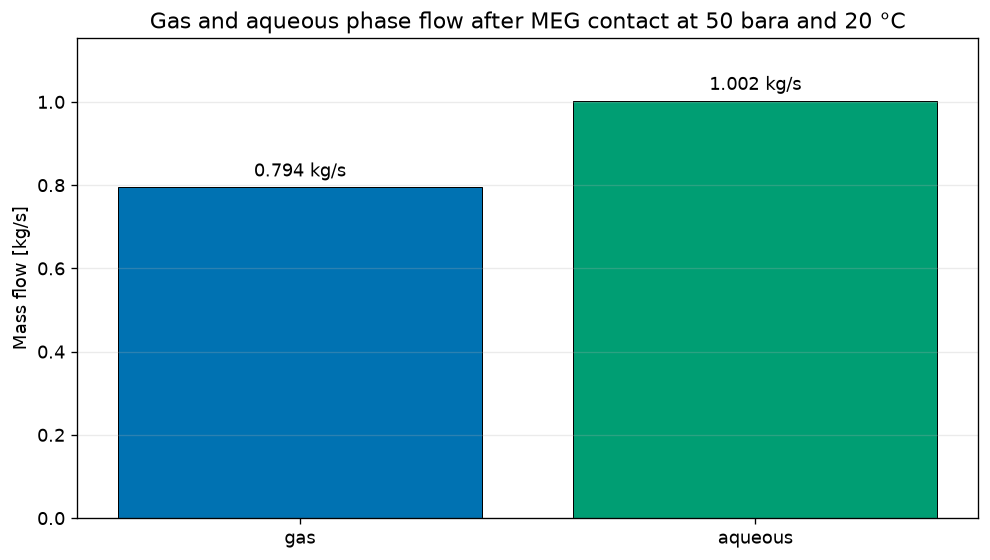

In [6]:
phase_names = contact_results["Phase"].tolist()
phase_flows = contact_results["Mass flow [kg/s]"].to_numpy()

fig, ax = plt.subplots()
bars = ax.bar(
    phase_names,
    phase_flows,
    color=[COLORS["blue"], COLORS["green"]],
    edgecolor="black",
    linewidth=0.6,
)
ax.bar_label(
    bars,
    labels=[f"{value:.3f} kg/s" for value in phase_flows],
    padding=4,
)
ax.set_ylabel("Mass flow [kg/s]")
ax.set_title("Gas and aqueous phase flow after MEG contact at 50 bara and 20 °C")
ax.set_ylim(0.0, 1.15 * phase_flows.max())
ax.grid(axis="x", visible=False)
fig.tight_layout()

The aqueous outlet remains close to the injected solution flow because water and MEG are strongly
associated. The small difference from exactly 1 kg/s is physically useful: it represents dissolved
gas and the small amount of water and MEG transferred to the gas phase. The phase-split residual
checks that the reported phase rates reconstruct the total feed.

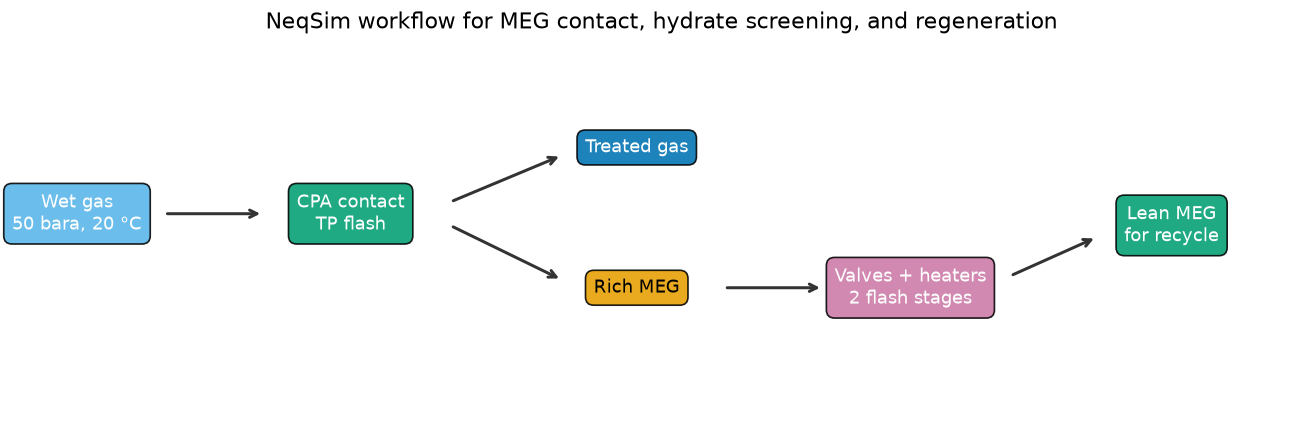

In [7]:
fig, ax = plt.subplots(figsize=(11.0, 3.8))
ax.axis("off")

boxes = [
    (0.03, 0.55, "Wet gas\n50 bara, 20 °C", COLORS["sky"]),
    (0.25, 0.55, "CPA contact\nTP flash", COLORS["green"]),
    (0.48, 0.72, "Treated gas", COLORS["blue"]),
    (0.48, 0.36, "Rich MEG", COLORS["orange"]),
    (0.70, 0.36, "Valves + heaters\n2 flash stages", COLORS["purple"]),
    (0.91, 0.52, "Lean MEG\nfor recycle", COLORS["green"]),
]

for x_position, y_position, label, color in boxes:
    ax.text(
        x_position,
        y_position,
        label,
        ha="center",
        va="center",
        transform=ax.transAxes,
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": color,
            "edgecolor": "black",
            "alpha": 0.88,
        },
        color="white" if color != COLORS["orange"] else "black",
    )

arrows = [
    ((0.10, 0.55), (0.18, 0.55)),
    ((0.33, 0.58), (0.42, 0.70)),
    ((0.33, 0.52), (0.42, 0.38)),
    ((0.55, 0.36), (0.63, 0.36)),
    ((0.78, 0.39), (0.85, 0.49)),
]
for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        xycoords=ax.transAxes,
        arrowprops={"arrowstyle": "->", "linewidth": 1.8, "color": "#333333"},
    )

ax.set_title("NeqSim workflow for MEG contact, hydrate screening, and regeneration")
fig.tight_layout()

## 2. Cooling the treated gas

Gas leaving the contact flash carries small equilibrium amounts of water and MEG. Cooling can create
an aqueous condensate even when the bulk contact calculation appears well separated. The following
sweep preserves the treated-gas composition from the 20 °C contact flash and performs an independent
TP flash at each colder temperature.

The plotted aqueous fraction is a mass fraction of the treated stream. The composition of that
aqueous phase shows whether the dropout is mainly water or MEG.

In [8]:
cooling_temperatures_c = np.array(
    [
        0.0,
        3.0,
        6.0,
        9.0,
        12.0,
        15.0,
        18.0,
    ]
)
aqueous_mass_fractions = []
aqueous_water_fractions = []

for temperature_c in cooling_temperatures_c:
    cooled_gas = treated_gas.clone()
    cooled_gas.setMultiPhaseCheck(True)
    cooled_gas.setTemperature(temperature_c, "C")
    TPflash(cooled_gas)

    if cooled_gas.hasPhaseType("aqueous"):
        aqueous_index = cooled_gas.getPhaseNumberOfPhase("aqueous")
        aqueous_phase = cooled_gas.getPhase(aqueous_index)
        aqueous_mass_fractions.append(
            cooled_gas.getWtFraction(aqueous_index)
        )
        aqueous_water_fractions.append(
            aqueous_phase.getWtFrac("water")
        )
    else:
        aqueous_mass_fractions.append(0.0)
        aqueous_water_fractions.append(np.nan)

cooling_results = pd.DataFrame(
    {
        "Temperature [°C]": cooling_temperatures_c,
        "Aqueous stream fraction [kg/kg]": aqueous_mass_fractions,
        "Water in aqueous phase [kg/kg]": aqueous_water_fractions,
    }
)
print(
    cooling_results.to_string(
        index=False,
        float_format=lambda value: f"{value:.6g}",
    )
)

assert aqueous_mass_fractions[0] > aqueous_mass_fractions[-1]
assert np.nanmin(aqueous_water_fractions) > 0.50

 Temperature [°C]  Aqueous stream fraction [kg/kg]  Water in aqueous phase [kg/kg]
                0                      0.000253407                        0.987144
                3                      0.000218742                        0.985835
                6                       0.00017747                        0.983444
                9                      0.000128684                        0.978445
               12                      7.20611e-05                        0.963977
               15                      1.77888e-05                        0.870881
               18                      3.23259e-06                        0.624681


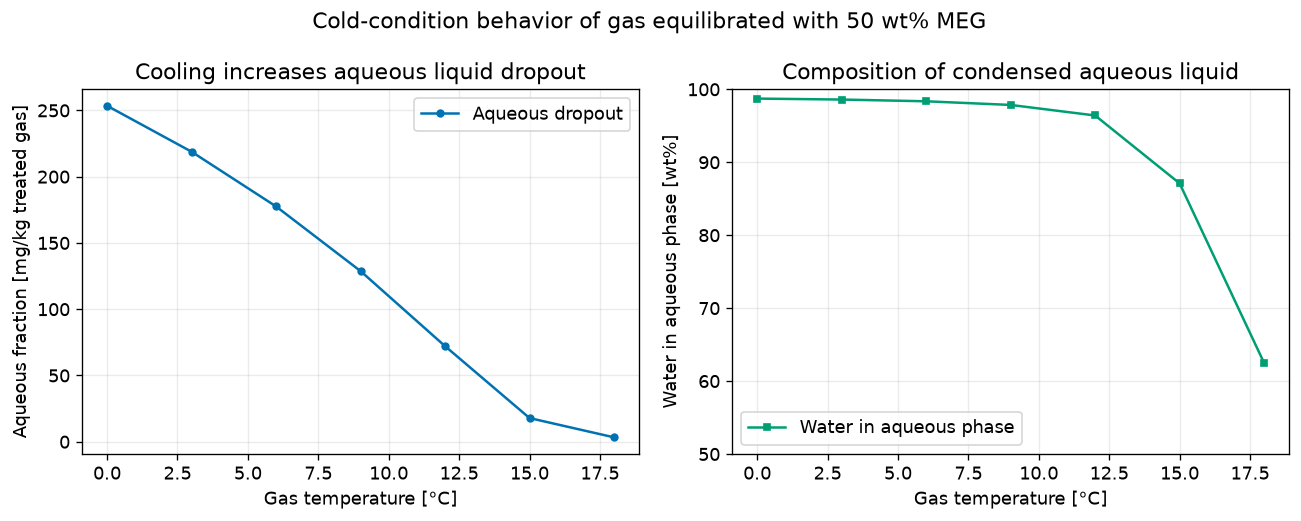

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))

axes[0].plot(
    cooling_temperatures_c,
    1.0e6 * np.array(aqueous_mass_fractions),
    color=COLORS["blue"],
    marker="o",
    markersize=4,
    label="Aqueous dropout",
)
axes[0].set_xlabel("Gas temperature [°C]")
axes[0].set_ylabel("Aqueous fraction [mg/kg treated gas]")
axes[0].set_title("Cooling increases aqueous liquid dropout")
axes[0].legend()

axes[1].plot(
    cooling_temperatures_c,
    100.0 * np.array(aqueous_water_fractions),
    color=COLORS["green"],
    marker="s",
    markersize=4,
    label="Water in aqueous phase",
)
axes[1].set_xlabel("Gas temperature [°C]")
axes[1].set_ylabel("Water in aqueous phase [wt%]")
axes[1].set_title("Composition of condensed aqueous liquid")
axes[1].set_ylim(50.0, 100.0)
axes[1].legend()

fig.suptitle("Cold-condition behavior of gas equilibrated with 50 wt% MEG")
fig.tight_layout()

The colder cases produce more aqueous liquid, and that liquid is water-rich. Even a small total
dropout can matter in low points, valves, and instrumentation. A piping study should therefore use
both hydrate margin and predicted liquid inventory; hydrate temperature alone is not an operability
criterion.

## 3. Rich-MEG regeneration process

The rich aqueous phase from the contact flash becomes a named NeqSim stream. A first pressure letdown
and 90 °C flash remove dissolved gas. A second letdown to 1.3 bara and a reboiler flash water from
the solution. `ProcessSystem` supplies the solver order, while valves, heaters, and separators pass
thermodynamic outlet streams to downstream equipment.

For component $i$, the steady-state balance is:

$$
\dot m_{i,\mathrm{feed}}=\sum_k \dot m_{i,k,\mathrm{out}}
$$

The relative residual and specific reboiler duty are:

$$
r_i=\frac{\sum_k \dot m_{i,k,\mathrm{out}}-\dot m_{i,\mathrm{feed}}}
{\dot m_{i,\mathrm{feed}}}
$$

$$
q_{\mathrm{reb}}=\frac{Q_{\mathrm{reb}}}{\dot m_{\mathrm{rich}}}
$$

Here $\dot m_i$ is component mass flow in kg/s, $Q_{\mathrm{reb}}$ is duty in kW, and
$q_{\mathrm{reb}}$ is kJ/kg rich solution.

In [10]:
def build_regeneration_process(
    rich_meg_system,
    reboiler_temperature_c=135.0,
):
    process = newProcess("MEG regeneration")
    rich_feed = stream(
        "rich MEG feed",
        rich_meg_system.clone(),
        process=process,
    )

    flash_valve = valve(
        "rich MEG flash valve",
        rich_feed,
        p=3.0,
        process=process,
    )
    flash_heater = heater(
        "rich MEG flash heater",
        flash_valve.getOutletStream(),
        process=process,
    )
    flash_heater.setOutTemperature(90.0 + 273.15)

    flash_separator = separator(
        "dissolved-gas separator",
        flash_heater.getOutletStream(),
        process=process,
    )
    regenerator_valve = valve(
        "regenerator pressure valve",
        flash_separator.getLiquidOutStream(),
        p=1.3,
        process=process,
    )
    reboiler = heater(
        "MEG reboiler",
        regenerator_valve.getOutletStream(),
        process=process,
    )
    reboiler.setOutTemperature(reboiler_temperature_c + 273.15)

    regenerator_separator = separator(
        "regenerator flash separator",
        reboiler.getOutletStream(),
        process=process,
    )
    return {
        "process": process,
        "feed": rich_feed,
        "flash_gas": flash_separator.getGasOutStream(),
        "overhead": regenerator_separator.getGasOutStream(),
        "lean_meg": regenerator_separator.getLiquidOutStream(),
        "flash_heater": flash_heater,
        "reboiler": reboiler,
    }


def component_mass_flow(stream_object, component):
    return (
        stream_object
        .getThermoSystem()
        .getComponent(component)
        .getFlowRate("kg/sec")
    )

In [11]:
base_regeneration = build_regeneration_process(
    rich_meg,
    reboiler_temperature_c=135.0,
)
base_regeneration["process"].run()

stream_rows = []
for stream_name in ["feed", "flash_gas", "overhead", "lean_meg"]:
    stream_object = base_regeneration[stream_name]
    thermo_system = stream_object.getThermoSystem()
    phase = thermo_system.getPhase(0)
    stream_rows.append(
        {
            "Stream": stream_name,
            "Flow [kg/s]": thermo_system.getFlowRate("kg/sec"),
            "Temperature [°C]": thermo_system.getTemperature("C"),
            "Pressure [bara]": thermo_system.getPressure("bara"),
            "Water [kg/kg]": phase.getWtFrac("water"),
            "MEG [kg/kg]": phase.getWtFrac("MEG"),
        }
    )

base_stream_table = pd.DataFrame(stream_rows)
print(
    base_stream_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

   Stream  Flow [kg/s]  Temperature [°C]  Pressure [bara]  Water [kg/kg]  MEG [kg/kg]
     feed     1.002048         20.000000        50.000000       0.498657     0.498976
flash_gas     0.002386         90.000000         3.000000       0.139540     0.002754
 overhead     0.498714        135.000000         1.300000       0.834555     0.164794
 lean_meg     0.500948        135.000000         1.300000       0.165968     0.834032


In [12]:
outlet_names = ["flash_gas", "overhead", "lean_meg"]
balance_rows = []

for component in ["water", "MEG"]:
    feed_rate = component_mass_flow(
        base_regeneration["feed"],
        component,
    )
    outlet_rate = sum(
        component_mass_flow(
            base_regeneration[outlet_name],
            component,
        )
        for outlet_name in outlet_names
    )
    relative_residual = (outlet_rate - feed_rate) / feed_rate
    balance_rows.append(
        {
            "Component": component,
            "Feed [kg/s]": feed_rate,
            "Outlets [kg/s]": outlet_rate,
            "Relative residual [-]": relative_residual,
        }
    )

feed_total = (
    base_regeneration["feed"]
    .getThermoSystem()
    .getFlowRate("kg/sec")
)
outlet_total = sum(
    base_regeneration[outlet_name]
    .getThermoSystem()
    .getFlowRate("kg/sec")
    for outlet_name in outlet_names
)
total_residual = (outlet_total - feed_total) / feed_total

balance_table = pd.DataFrame(balance_rows)
print(
    balance_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.3e}",
    )
)
print(f"Total mass residual: {total_residual:.3e}")

assert abs(total_residual) < 1.0e-10
assert np.max(np.abs(balance_table["Relative residual [-]"])) < 1.0e-10

Component  Feed [kg/s]  Outlets [kg/s]  Relative residual [-]
    water    4.997e-01       4.997e-01             -5.557e-13
      MEG    5.000e-01       5.000e-01             -9.067e-13
Total mass residual: -4.977e-13


The dissolved-gas flash has a small mass flow but is important for safe regenerator pressure
control. The low-pressure stage removes water and increases MEG concentration in the remaining
liquid. Water and MEG balances include all three outlets; omitting flash gas or overhead would make
the apparent recovery misleading.

### Regeneration-temperature sensitivity

A higher reboiler temperature removes more water, but also increases duty and MEG in the overhead.
Each point below builds and runs an independent process from the same rich-MEG state. The simple
equilibrium flash is intentionally not presented as a distillation-column design.

In [13]:
reboiler_temperatures_c = np.array(
    [
        120.0,
        125.0,
        130.0,
        135.0,
        140.0,
    ]
)
regeneration_records = []

for reboiler_temperature_c in reboiler_temperatures_c:
    regeneration_case = build_regeneration_process(
        rich_meg,
        reboiler_temperature_c=reboiler_temperature_c,
    )
    regeneration_case["process"].run()

    feed_system = regeneration_case["feed"].getThermoSystem()
    lean_system = regeneration_case["lean_meg"].getThermoSystem()
    overhead_system = regeneration_case["overhead"].getThermoSystem()

    lean_phase = lean_system.getPhase(0)
    overhead_phase = overhead_system.getPhase(0)
    reboiler_duty_kw = regeneration_case["reboiler"].getDuty() / 1.0e3
    feed_rate_kg_s = feed_system.getFlowRate("kg/sec")

    regeneration_records.append(
        {
            "Reboiler temperature [°C]": reboiler_temperature_c,
            "Lean MEG [wt%]": 100.0 * lean_phase.getWtFrac("MEG"),
            "Overhead MEG [wt%]": 100.0 * overhead_phase.getWtFrac("MEG"),
            "Lean flow [kg/s]": lean_system.getFlowRate("kg/sec"),
            "Overhead flow [kg/s]": overhead_system.getFlowRate("kg/sec"),
            "Reboiler duty [kW]": reboiler_duty_kw,
            "Specific duty [kJ/kg rich]": reboiler_duty_kw / feed_rate_kg_s,
        }
    )

regeneration_sensitivity = pd.DataFrame(regeneration_records)
print(
    regeneration_sensitivity.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

assert np.all(np.diff(regeneration_sensitivity["Lean MEG [wt%]"]) > 0.0)
assert np.all(np.diff(regeneration_sensitivity["Reboiler duty [kW]"]) > 0.0)

 Reboiler temperature [°C]  Lean MEG [wt%]  Overhead MEG [wt%]  Lean flow [kg/s]  Overhead flow [kg/s]  Reboiler duty [kW]  Specific duty [kJ/kg rich]
                   120.000          62.765               5.262             0.778                 0.222             581.315                     580.128
                   125.000          72.336               8.407             0.651                 0.349             855.401                     853.653
                   130.000          78.818              12.144             0.568                 0.432            1022.870                    1020.779
                   135.000          83.403              16.479             0.501                 0.499            1145.838                    1143.497
                   140.000          86.775              21.401             0.438                 0.562            1249.668                    1247.114


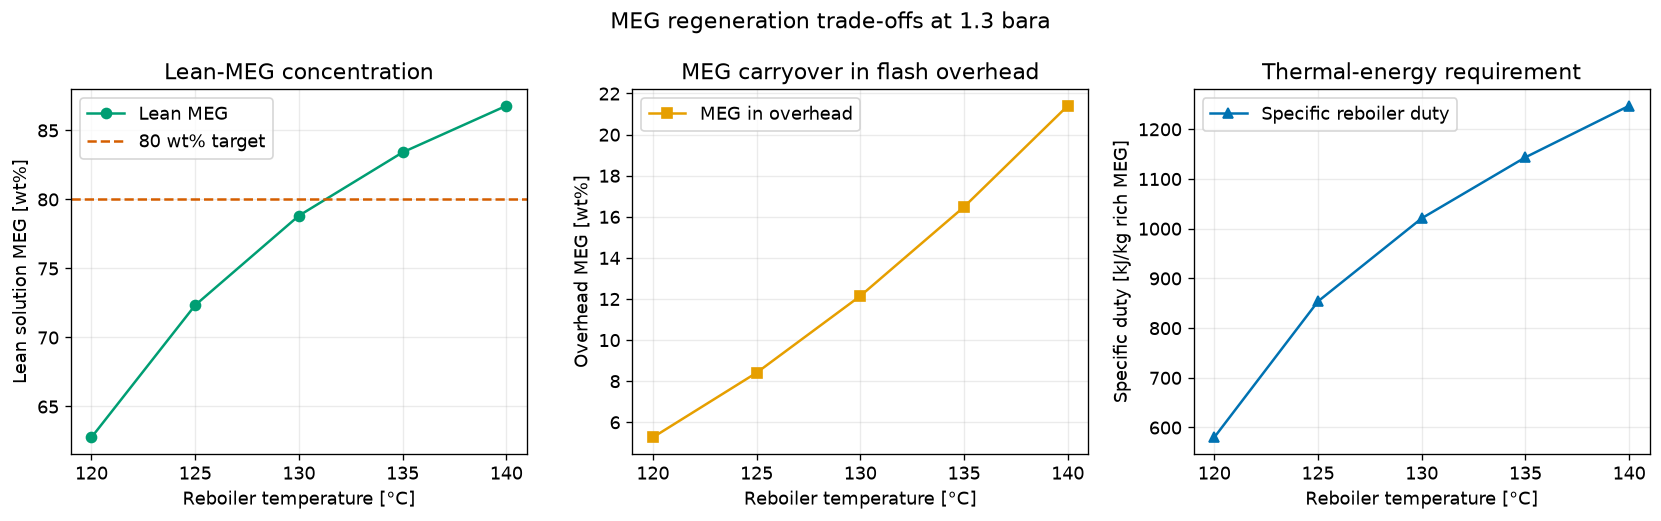

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))

axes[0].plot(
    reboiler_temperatures_c,
    regeneration_sensitivity["Lean MEG [wt%]"],
    marker="o",
    color=COLORS["green"],
    label="Lean MEG",
)
axes[0].axhline(
    80.0,
    color=COLORS["red"],
    linestyle="--",
    label="80 wt% target",
)
axes[0].set_xlabel("Reboiler temperature [°C]")
axes[0].set_ylabel("Lean solution MEG [wt%]")
axes[0].set_title("Lean-MEG concentration")
axes[0].legend()

axes[1].plot(
    reboiler_temperatures_c,
    regeneration_sensitivity["Overhead MEG [wt%]"],
    marker="s",
    color=COLORS["orange"],
    label="MEG in overhead",
)
axes[1].set_xlabel("Reboiler temperature [°C]")
axes[1].set_ylabel("Overhead MEG [wt%]")
axes[1].set_title("MEG carryover in flash overhead")
axes[1].legend()

axes[2].plot(
    reboiler_temperatures_c,
    regeneration_sensitivity["Specific duty [kJ/kg rich]"],
    marker="^",
    color=COLORS["blue"],
    label="Specific reboiler duty",
)
axes[2].set_xlabel("Reboiler temperature [°C]")
axes[2].set_ylabel("Specific duty [kJ/kg rich MEG]")
axes[2].set_title("Thermal-energy requirement")
axes[2].legend()

fig.suptitle("MEG regeneration trade-offs at 1.3 bara")
fig.tight_layout()

The sensitivity demonstrates the expected trade-off: hotter regeneration produces a leaner
solution but requires more heat and increases MEG in the overhead. A real unit normally uses
structured separation, reflux, heat recovery, and MEG recovery from the overhead. Those features
change the quantitative optimum but not the need to evaluate concentration, loss, and duty
together.

## 4. Hydrate boundary and operating margin

NeqSim's hydrate calculation introduces a hydrate phase and solves for the equilibrium temperature
at the specified pressure and overall composition. The MEG concentration is defined on a water–MEG
mass basis:

$$
w_{\mathrm{MEG}}=\frac{\dot m_{\mathrm{MEG}}}
{\dot m_{\mathrm{MEG}}+\dot m_{\mathrm{water}}}
$$

The operating margin is positive when the process temperature is above the calculated hydrate
boundary:

$$
\Delta T_{\mathrm{safe}}=T_{\mathrm{op}}-T_{\mathrm{hyd}}
$$

Both temperatures use °C in the subtraction, so $\Delta T_{\mathrm{safe}}$ is in K. This is an
equilibrium margin; it does not represent hydrate kinetics, cold spots, or measurement uncertainty.

Each hydrate sweep is sent to a clean Python/Java worker. The worker constructs a fresh CPA system
for every case, calls NeqSim's native `hydt` operation, and returns only the calculated temperatures.
This keeps the solid-phase calculation independent from the earlier process-system state and makes
the sensitivity reproducible.

In [15]:
HYDRATE_WORKER_SOURCE = r'''
import json
import sys

from neqsim.thermo import fluid, hydt

payload = json.loads(sys.stdin.read())
results = []

for case in payload["cases"]:
    test_fluid = fluid("cpa")
    for component, mole_fraction in zip(
        payload["components"],
        payload["mole_fractions"],
    ):
        component_rate = mole_fraction * payload["gas_rate_sm3_s"]
        test_fluid.addComponent(
            component,
            component_rate,
            "Sm3/sec",
        )

    meg_fraction = case["meg_mass_fraction"]
    aqueous_rate = payload["aqueous_rate_kg_s"]
    test_fluid.addComponent(
        "water",
        (1.0 - meg_fraction) * aqueous_rate,
        "kg/sec",
    )
    if meg_fraction > 0.0:
        test_fluid.addComponent(
            "MEG",
            meg_fraction * aqueous_rate,
            "kg/sec",
        )

    test_fluid.setMixingRule(10)
    test_fluid.setHydrateCheck(True)
    test_fluid.setPressure(
        case["pressure_bara"],
        "bara",
    )
    test_fluid.setTemperature(5.0, "C")
    hydrate_temperature_k = hydt(test_fluid)
    results.append(hydrate_temperature_k - 273.15)

print(json.dumps(results))
'''


def calculate_hydrate_cases(cases):
    payload = {
        "components": GAS_COMPONENTS,
        "mole_fractions": GAS_MOLE_FRACTIONS.tolist(),
        "gas_rate_sm3_s": GAS_RATE_SM3_S,
        "aqueous_rate_kg_s": AQUEOUS_RATE_KG_S,
        "cases": cases,
    }
    completed = subprocess.run(
        [
            sys.executable,
            "-c",
            HYDRATE_WORKER_SOURCE,
        ],
        input=json.dumps(payload),
        text=True,
        capture_output=True,
        check=True,
    )
    return np.array(json.loads(completed.stdout))


base_hydrate_cases = [
    {
        "meg_mass_fraction": 0.0,
        "pressure_bara": CONTACT_PRESSURE_BARA,
    },
    {
        "meg_mass_fraction": BASE_MEG_MASS_FRACTION,
        "pressure_bara": CONTACT_PRESSURE_BARA,
    },
]
untreated_hydrate_c, inhibited_hydrate_c = calculate_hydrate_cases(
    base_hydrate_cases
)
operating_temperature_c = 5.0
hydrate_margin_k = operating_temperature_c - inhibited_hydrate_c

comparison = pd.DataFrame(
    {
        "Case": ["Water only", "50 wt% MEG solution"],
        "Hydrate equilibrium [°C]": [
            untreated_hydrate_c,
            inhibited_hydrate_c,
        ],
    }
)
print(comparison.to_string(index=False, float_format=lambda value: f"{value:.3f}"))
print(f"Hydrate margin at 5 °C with 50 wt% MEG: {hydrate_margin_k:.3f} K")

assert untreated_hydrate_c > inhibited_hydrate_c
assert hydrate_margin_k > 0.0

               Case  Hydrate equilibrium [°C]
         Water only                    15.761
50 wt% MEG solution                    -4.755
Hydrate margin at 5 °C with 50 wt% MEG: 9.755 K


### MEG concentration sensitivity

A hydrate inhibitor should be selected from an operating envelope, not from one nominal point. The
next sweep holds gas rate, aqueous rate, pressure, and composition fixed while varying only the MEG
mass fraction. A fresh thermodynamic system is created for each point to avoid hidden solver state.

In [16]:
meg_mass_fractions = np.array(
    [
        0.00,
        0.20,
        0.30,
        0.40,
        0.50,
        0.60,
        0.70,
    ]
)
concentration_cases = [
    {
        "meg_mass_fraction": meg_fraction,
        "pressure_bara": CONTACT_PRESSURE_BARA,
    }
    for meg_fraction in meg_mass_fractions
]
hydrate_temperatures_c = calculate_hydrate_cases(
    concentration_cases
)

hydrate_sensitivity = pd.DataFrame(
    {
        "MEG [wt%]": 100.0 * meg_mass_fractions,
        "Hydrate equilibrium [°C]": hydrate_temperatures_c,
        "Margin at 5 °C [K]": operating_temperature_c - hydrate_temperatures_c,
    }
)
print(
    hydrate_sensitivity.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

assert np.all(np.diff(hydrate_temperatures_c) < 0.0)

 MEG [wt%]  Hydrate equilibrium [°C]  Margin at 5 °C [K]
     0.000                    15.761             -10.761
    20.000                    10.351              -5.351
    30.000                     6.413              -1.413
    40.000                     1.468               3.532
    50.000                    -4.755               9.755
    60.000                   -12.754              17.754
    70.000                   -23.784              28.784


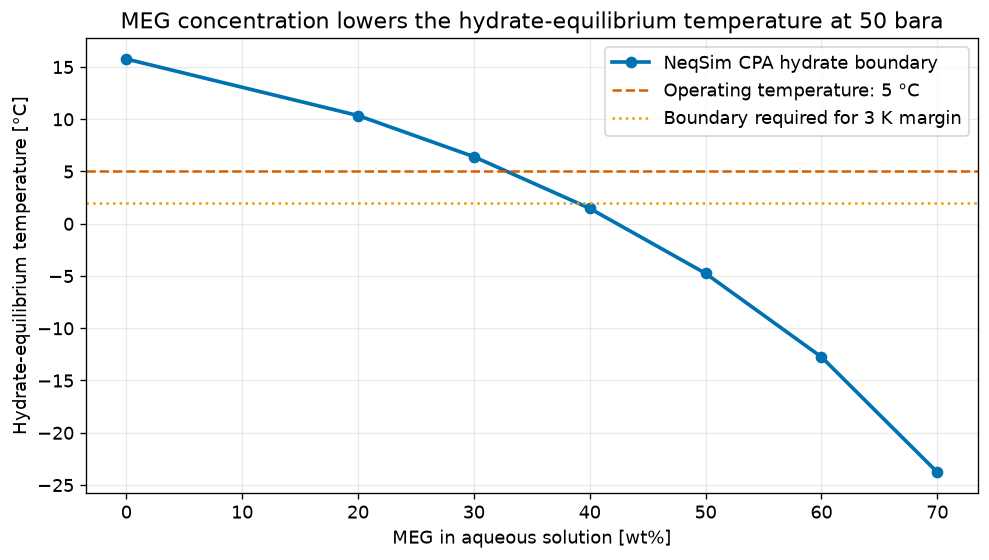

In [17]:
fig, ax = plt.subplots()
ax.plot(
    100.0 * meg_mass_fractions,
    hydrate_temperatures_c,
    marker="o",
    linewidth=2.2,
    color=COLORS["blue"],
    label="NeqSim CPA hydrate boundary",
)
ax.axhline(
    operating_temperature_c,
    color=COLORS["red"],
    linestyle="--",
    label="Operating temperature: 5 °C",
)
ax.axhline(
    operating_temperature_c - 3.0,
    color=COLORS["orange"],
    linestyle=":",
    label="Boundary required for 3 K margin",
)
ax.set_xlabel("MEG in aqueous solution [wt%]")
ax.set_ylabel("Hydrate-equilibrium temperature [°C]")
ax.set_title("MEG concentration lowers the hydrate-equilibrium temperature at 50 bara")
ax.legend(loc="best")
fig.tight_layout()

The curve is monotonic over the tested range. For this gas and pressure, 40 wt% MEG moves the
equilibrium boundary below 2 °C, giving more than 3 K margin at a 5 °C operating temperature.
The result is specific to the gas composition, pressure, and water–MEG basis used here.

### Pressure sensitivity

Higher gas pressure generally stabilizes hydrates. The pressure sweep repeats the full hydrate
calculation for water-only and inhibited systems. This is more informative than applying one
temperature depression at every pressure.

In [18]:
pressure_points_bara = np.array(
    [
        30.0,
        50.0,
        70.0,
        90.0,
    ]
)
pressure_cases = {
    "Water only": 0.0,
    "40 wt% MEG": 0.40,
    "50 wt% MEG": 0.50,
}

pressure_records = []
pressure_case_definitions = [
    {
        "case_name": case_name,
        "meg_mass_fraction": meg_fraction,
        "pressure_bara": pressure_bara,
    }
    for case_name, meg_fraction in pressure_cases.items()
    for pressure_bara in pressure_points_bara
]
pressure_hydrate_temperatures = calculate_hydrate_cases(
    [
        {
            "meg_mass_fraction": case["meg_mass_fraction"],
            "pressure_bara": case["pressure_bara"],
        }
        for case in pressure_case_definitions
    ]
)

for case, hydrate_c in zip(
    pressure_case_definitions,
    pressure_hydrate_temperatures,
):
    pressure_records.append(
        {
            "Case": case["case_name"],
            "Pressure [bara]": case["pressure_bara"],
            "Hydrate equilibrium [°C]": hydrate_c,
        }
    )

pressure_sensitivity = pd.DataFrame(pressure_records)
print(
    pressure_sensitivity.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

      Case  Pressure [bara]  Hydrate equilibrium [°C]
Water only           30.000                    11.932
Water only           50.000                    15.761
Water only           70.000                    17.984
Water only           90.000                    19.422
40 wt% MEG           30.000                    -2.162
40 wt% MEG           50.000                     1.468
40 wt% MEG           70.000                     3.449
40 wt% MEG           90.000                     4.634
50 wt% MEG           30.000                    -8.273
50 wt% MEG           50.000                    -4.755
50 wt% MEG           70.000                    -2.907
50 wt% MEG           90.000                    -1.863


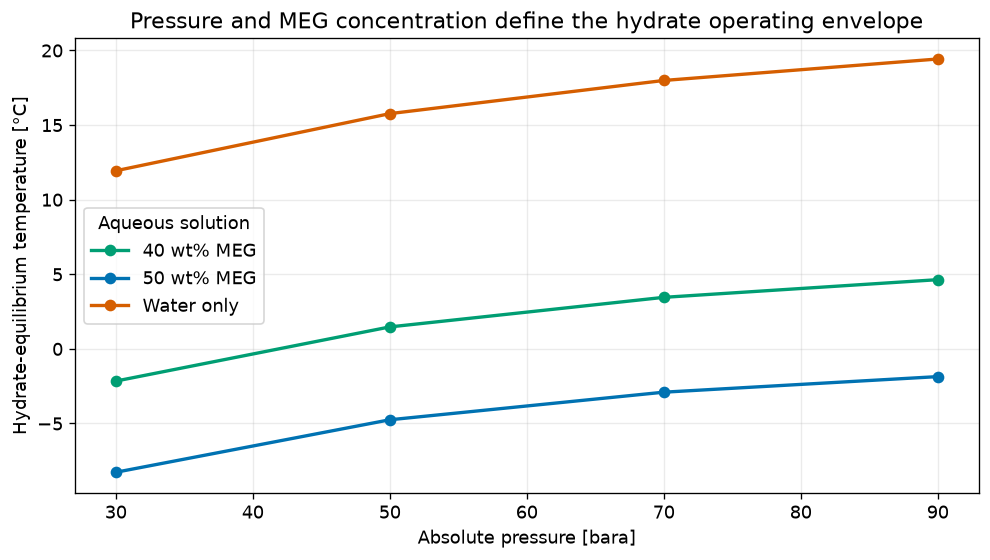

In [19]:
fig, ax = plt.subplots()
case_colors = {
    "Water only": COLORS["red"],
    "40 wt% MEG": COLORS["green"],
    "50 wt% MEG": COLORS["blue"],
}

for case_name, case_data in pressure_sensitivity.groupby("Case"):
    ax.plot(
        case_data["Pressure [bara]"],
        case_data["Hydrate equilibrium [°C]"],
        marker="o",
        linewidth=2.0,
        color=case_colors[case_name],
        label=case_name,
    )

ax.set_xlabel("Absolute pressure [bara]")
ax.set_ylabel("Hydrate-equilibrium temperature [°C]")
ax.set_title("Pressure and MEG concentration define the hydrate operating envelope")
ax.legend(title="Aqueous solution")
fig.tight_layout()

At every pressure, MEG shifts the hydrate boundary downward. The upward pressure trend is a useful
physical check on the calculations. For a project, the tested range should cover startup, turndown,
shut-in, and pressure-control uncertainty rather than only normal operation.

## 5. Practical application: choose contact and regeneration conditions

The screening criteria are:

- minimum cold operating temperature: **5 °C** at **50 bara**;
- minimum equilibrium hydrate margin: **3 K**;
- lean solution from regeneration: at least **80 wt% MEG**;
- overhead composition: no more than **20 wt% MEG** in this simple flash model.

The first criterion selects the lowest tested contact-solution concentration whose hydrate
boundary is at or below 2 °C. The regeneration criteria select the lowest tested reboiler
temperature meeting both concentration and overhead limits. These are illustrative project
criteria, not universal design limits.

In [20]:
required_boundary_c = operating_temperature_c - 3.0
hydrate_candidates = hydrate_sensitivity[
    hydrate_sensitivity["Hydrate equilibrium [°C]"] <= required_boundary_c
]
selected_contact_meg_wt = hydrate_candidates.iloc[0]["MEG [wt%]"]
selected_hydrate_c = hydrate_candidates.iloc[0]["Hydrate equilibrium [°C]"]
selected_margin_k = operating_temperature_c - selected_hydrate_c

regeneration_candidates = regeneration_sensitivity[
    (regeneration_sensitivity["Lean MEG [wt%]"] >= 80.0)
    & (regeneration_sensitivity["Overhead MEG [wt%]"] <= 20.0)
]
selected_regeneration = regeneration_candidates.iloc[0]

application_results = pd.DataFrame(
    {
        "Decision": [
            "Contact solution",
            "Hydrate boundary",
            "Hydrate margin",
            "Reboiler temperature",
            "Lean MEG",
            "Overhead MEG",
            "Specific duty",
        ],
        "Value": [
            selected_contact_meg_wt,
            selected_hydrate_c,
            selected_margin_k,
            selected_regeneration["Reboiler temperature [°C]"],
            selected_regeneration["Lean MEG [wt%]"],
            selected_regeneration["Overhead MEG [wt%]"],
            selected_regeneration["Specific duty [kJ/kg rich]"],
        ],
        "Unit": [
            "wt% MEG",
            "°C",
            "K",
            "°C",
            "wt% MEG",
            "wt% MEG",
            "kJ/kg rich MEG",
        ],
    }
)
print(
    application_results.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

assert selected_margin_k >= 3.0
assert selected_regeneration["Lean MEG [wt%]"] >= 80.0
assert selected_regeneration["Overhead MEG [wt%]"] <= 20.0

            Decision    Value           Unit
    Contact solution   40.000        wt% MEG
    Hydrate boundary    1.468             °C
      Hydrate margin    3.532              K
Reboiler temperature  135.000             °C
            Lean MEG   83.403        wt% MEG
        Overhead MEG   16.479        wt% MEG
       Specific duty 1143.497 kJ/kg rich MEG


In [21]:
engineering_checks = {
    "gas composition closes": np.isclose(GAS_MOLE_FRACTIONS.sum(), 1.0),
    "gas phase exists": contact_fluid.hasPhaseType("gas"),
    "aqueous phase exists": contact_fluid.hasPhaseType("aqueous"),
    "contact phase balance closes": abs(phase_closure) < 1.0e-10,
    "MEG lowers hydrate temperature": untreated_hydrate_c > inhibited_hydrate_c,
    "hydrate curve is monotonic": np.all(np.diff(hydrate_temperatures_c) < 0.0),
    "cold sweep has more liquid": (
        aqueous_mass_fractions[0] > aqueous_mass_fractions[-1]
    ),
    "total regeneration balance closes": abs(total_residual) < 1.0e-10,
    "water and MEG balances close": (
        np.max(np.abs(balance_table["Relative residual [-]"])) < 1.0e-10
    ),
    "lean concentration rises with temperature": np.all(
        np.diff(regeneration_sensitivity["Lean MEG [wt%]"]) > 0.0
    ),
    "duty rises with temperature": np.all(
        np.diff(regeneration_sensitivity["Reboiler duty [kW]"]) > 0.0
    ),
    "selected hydrate margin passes": selected_margin_k >= 3.0,
    "selected lean concentration passes": (
        selected_regeneration["Lean MEG [wt%]"] >= 80.0
    ),
    "selected overhead criterion passes": (
        selected_regeneration["Overhead MEG [wt%]"] <= 20.0
    ),
}

failed_checks = [
    name
    for name, passed in engineering_checks.items()
    if not passed
]
print(f"Engineering checks passed: {len(engineering_checks) - len(failed_checks)}")
print(f"Engineering checks failed: {len(failed_checks)}")
if failed_checks:
    print("\n".join(failed_checks))

assert not failed_checks

Engineering checks passed: 14
Engineering checks failed: 0


## Troubleshooting

- **Only one phase appears:** confirm that water is present, `setMultiPhaseCheck(True)` is called,
  and the contact temperature and pressure are set before `TPflash`.
- **Hydrate calculation fails to converge:** create a fresh system, include enough water to define
  an aqueous/hydrate equilibrium, set a realistic initial temperature, and avoid reusing a
  post-flash gas-only object as the hydrate basis.
- **A phase index changes:** retrieve phases by type (`gas` or `aqueous`) instead of assuming a
  fixed numeric index.
- **Regenerator balance appears open:** include flash gas, overhead vapor, and lean liquid in the
  outlet sum.
- **Results change after editing a cell:** restart the runtime and execute all cells from the top;
  every scenario helper here constructs an independent NeqSim system.

## Applicability and limitations

CPA provides a rigorous equilibrium framework for the gas–water–MEG system, but an engineering
design requires more than equilibrium. Validate binary parameters and feed composition against
laboratory data. Add salts and produced-water chemistry when relevant. Account for hydrate kinetics,
subcooling history, insulation, terrain, liquid holdup, shutdown duration, mixing quality, and
MEG distribution.

The regeneration model contains two equilibrium flash vessels rather than a rated stripping
column. It does not include degradation products, corrosion, foaming, solids, reclaimer service,
vacuum operation, heat integration, or equipment limits. Use it to establish transparent balances
and sensitivities before moving to a detailed column and mechanical design.

## Summary

- NeqSim CPA represented gas, water, and MEG in one composable thermodynamic system.
- The contact TP flash supplied treated-gas and rich-MEG states for downstream calculations.
- MEG concentration and pressure were evaluated through native hydrate-equilibrium calculations.
- Cooling the treated gas revealed a small, water-rich aqueous dropout.
- A named process model connected valves, heaters, and separators for rich-MEG regeneration.
- Total, water, and MEG balances closed, and monotonic sensitivity checks passed.
- The illustrative criteria selected 40 wt% contact solution and a 135 °C reboiler case.

## Exercises

1. Replace the synthetic gas with a project composition and repeat the pressure envelope.
2. Add NaCl using an electrolyte-capable model and compare salt plus MEG inhibition.
3. Vary gas and aqueous flow independently to study MEG circulation and rich-solution loading.
4. Add an overhead condenser and separator, then quantify recoverable MEG.
5. Connect a detailed regenerator or stripping-column model and compare it with the flash screen.
6. Couple the treated gas to a pipeline model and combine hydrate margin with liquid-holdup risk.

## References

- NeqSim documentation: [Thermodynamics](https://equinor.github.io/neqsim/thermo/)
- NeqSim documentation: [Process simulation](https://equinor.github.io/neqsim/process/)
- NeqSim source repository: [equinor/neqsim](https://github.com/equinor/neqsim)
- Sloan, E. D. and Koh, C. A., *Clathrate Hydrates of Natural Gases*, 3rd edition,
  CRC Press, 2007.
- GPSA, *Engineering Data Book*, sections on hydrate control and glycol systems.